In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
import numpy as np


In [3]:
df = pd.read_csv('preprocessed.csv', index_col=[0, 1])


# Create a new column 'subject_id' by extracting the unique identifier from the 'PROLIFIC_PID' column and give it an integer value
df['subject_id'] = df['PROLIFIC_PID'].astype('category').cat.codes

In [23]:
df=df[df.RT_filter]

Text(0.5, 1.0, 'Distribution of RT Differences (Red - Green)')

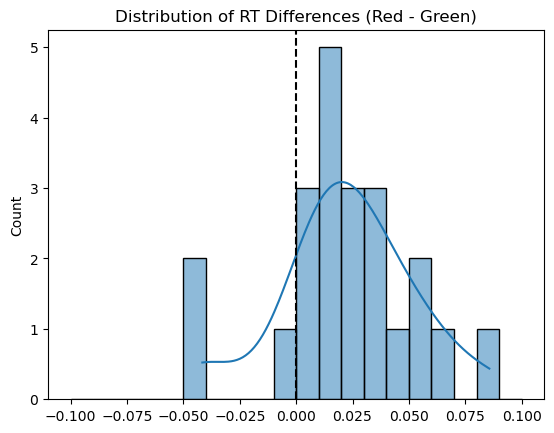

In [41]:
diff = df.pivot_table(index=['subject_id'], columns=['color'], values='logRT')

diff = diff['red'] - diff['green']

sns.histplot(diff, kde=True, bins=np.linspace(-.1, .1, 21))
plt.axvline(0.0, c='k', ls='--')

plt.title('Distribution of RT Differences (Red - Green)')

,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,color,0.013392,1,21,0.013392,8.170092,0.009410,0.009410,0.005421,1.000000
1,salience_bin,0.004798,2,42,0.002399,2.294406,0.113324,0.119463,0.001949,0.900616
2,color * salience_bin,0.000552,2,42,0.000276,0.487297,0.617714,0.612758,0.000225,0.973320


,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%]
0,Intercept,964.576045,20.926584,46.093335,7.310196e-73,0.002522,-0.006714,923.095926,1006.056165
1,salience,17.858223,34.172968,0.522583,6.023346e-01,0.002522,-0.006714,-49.878528,85.594975


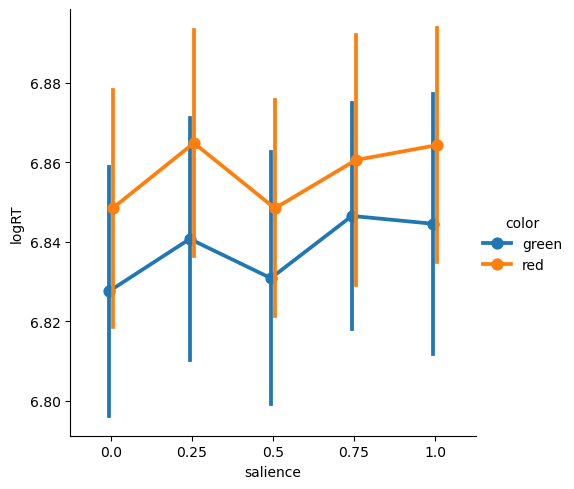

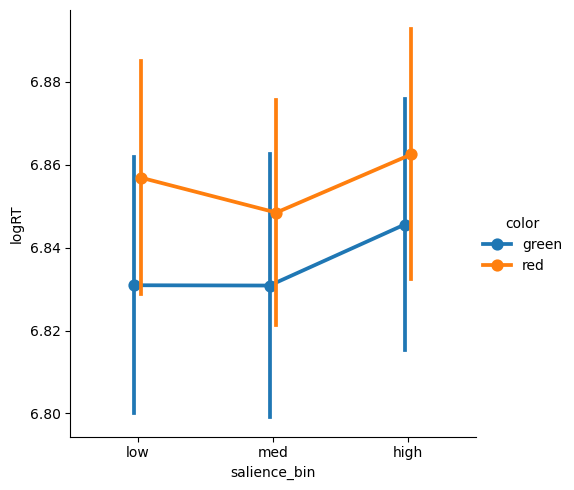

In [21]:
# step 1: plot results as a function of distractor color/salience
# 0-4 red (high to low salience), 5-9 green (high to low salience)
# X-axis: salience (0/5=high, 4/9=low), Color: red vs green, Overlapping points

df['salience'] = df['dist_col'].apply(lambda x: 1 - (x % 5) / 4)
df['color'] = df['dist_col'].apply(lambda x: 'red' if x < 5 else 'green')


sns.catplot(data=df[df.RT_filter].groupby(['subject_id', 'color', 'salience'])['logRT'].mean().reset_index(), x='salience', y='logRT', hue='color', kind='point', 
            errorbar='se', dodge=True)


df['salience_bin'] = pd.cut(df['salience'], bins=[-0.1, 0.4, 0.6, 1], labels=['low', 'med', 'high'])

sns.catplot(data=df[df.RT_filter].groupby(['subject_id', 'color', 'salience_bin'])['logRT'].mean().reset_index(), x='salience_bin', y='logRT', hue='color', kind='point',
            errorbar='se', dodge=True, order=['low', 'med', 'high'])


display(pg.rm_anova(data=df[df.RT_filter].groupby(['subject_id', 'color', 'salience_bin'])['logRT'].mean().reset_index(), dv='logRT', within=['color', 'salience_bin'], subject='subject_id'))


# Fit linear model to salience

tmp = df[df.RT_filter].groupby(['subject_id', 'salience'])['RT'].mean().reset_index()
pg.linear_regression(X=tmp['salience'], y=tmp['RT'])

In [7]:
import pingouin as pg
# Silence warnings
import warnings
warnings.filterwarnings('ignore')

from tqdm import tqdm
from itertools import product

import numpy as np

mean_rts = df[df.RT_filter].groupby(['subject_id', 'salience', 'color'])[['logRT']].mean()

mean_mean_rts = mean_rts.groupby(['salience', 'color'])['logRT'].mean()
cov = mean_rts.unstack(['salience', 'color']).cov()

mean_sd_rts = df[df.RT_filter].groupby(['subject_id', 'salience', 'color'])['logRT'].std().groupby(['salience', 'color']).mean()


def simulate_data(n_subject, n_trials, mean_mean_rts=mean_mean_rts, cov=cov, mean_sd_rts=mean_sd_rts):

    data = []

    for subject in range(n_subject):
        means_subject = np.random.multivariate_normal(mean_mean_rts.values.flatten(), cov)
        subject_data = np.random.normal(means_subject[np.newaxis, :], mean_sd_rts.values[np.newaxis, :], size=(n_trials, len(means_subject)))
        subject_data = pd.DataFrame(subject_data, columns=mean_mean_rts.index, index=pd.MultiIndex.from_product([[subject], range(1, n_trials+1)], names=['subject_id', 'trial']))

        data.append(subject_data)

    data = pd.concat(data, axis=0).stack(['salience', 'color']).to_frame('logRT')
    return data

def get_power(n_trials=[100, 250, 500, 1000], n_subjects=[10, 20, 30], n_simulations=1000):
    power_results = []

    for simulation in tqdm(range(n_simulations), desc='Simulations', maxinterval=n_simulations):
        data = simulate_data(np.max(n_subjects), np.max(n_trials)).reset_index()

        for n_sub, n_trial in product(n_subjects, n_trials):
            anova_result = pg.rm_anova(data=data[(data['trial'] <= n_trial) & (data['subject_id'] < n_sub+1)], dv='logRT', within=['salience', 'color'], subject='subject_id')
            # print(anova_result)

            for factor in anova_result['Source']:
                p_value = anova_result.loc[anova_result['Source'] == factor, 'p-unc'].values[0]
                power_results.append({'n_trials': n_trial, 'n_subjects': n_sub, 'factor': factor, 'p_value': p_value})

    power_df = pd.DataFrame(power_results)
    
    return power_df


power_results = get_power(n_simulations=10)

Simulations: 100%|██████████| 10/10 [00:03<00:00,  2.58it/s]


In [10]:
import pandas as pd
import numpy as np
import pingouin as pg
from tqdm import tqdm
from itertools import product
from joblib import Parallel, delayed
import warnings

# Precompute outside the function
mean_rts = df[df.RT_filter].groupby(['subject_id', 'salience', 'color'])[['logRT']].mean()
mean_mean_rts = mean_rts.groupby(['salience', 'color'])['logRT'].mean().sort_index()
cov = mean_rts.unstack(['salience', 'color']).cov()
cov += 1e-6 * np.eye(len(cov))  # Regularize covariance matrix
mean_sd_rts = df[df.RT_filter].groupby(['subject_id', 'salience', 'color'])['logRT'].std().groupby(['salience', 'color']).mean().sort_index()

def simulate_data(n_subject, n_trials, mean_mean_rts=mean_mean_rts, cov=cov, mean_sd_rts=mean_sd_rts):
    means_subjects = np.random.multivariate_normal(mean_mean_rts.values.flatten(), cov, size=n_subject)
    subject_data = np.random.normal(
        means_subjects[:, np.newaxis, :],
        mean_sd_rts.values[np.newaxis, np.newaxis, :],
        size=(n_subject, n_trials, len(mean_mean_rts))
    )
    index = pd.MultiIndex.from_product([range(n_subject), range(1, n_trials+1)], names=['subject_id', 'trial'])
    subject_data = pd.DataFrame(
        subject_data.reshape(n_subject * n_trials, -1),
        index=index,
        columns=mean_mean_rts.index
    )
    return subject_data.stack(['salience', 'color']).to_frame('logRT').reset_index()

def run_simulation(n_sub, n_trial):
    # Suppress warnings inside the parallel function
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=FutureWarning)
        data = simulate_data(n_sub, n_trial)
        anova_result = pg.rm_anova(data=data, dv='logRT', within=['salience', 'color'], subject='subject_id')
    return [
        {'n_trials': n_trial, 'n_subjects': n_sub, 'factor': factor, 'p_value': anova_result.loc[anova_result['Source'] == factor, 'p-unc'].values[0]}
        for factor in anova_result['Source']
    ]

def get_power(n_trials=[100, 250, 500, 1000], n_subjects=[10, 20, 30], n_simulations=1000, n_jobs=4):
    params = list(product(n_subjects, n_trials))
    results = Parallel(n_jobs=n_jobs)(
        delayed(run_simulation)(n_sub, n_trial)
        for _ in tqdm(range(n_simulations), desc='Simulations')
        for n_sub, n_trial in params
    )
    power_df = pd.DataFrame([item for sublist in results for item in sublist])
    return power_df

# Set random seed for reproducibility
np.random.seed(42)

# Run the power analysis
power_results = get_power(n_simulations=1000)


Simulations:   0%|          | 0/1000 [00:00<?, ?it/s]

Simulations: 100%|██████████| 1000/1000 [01:37<00:00, 10.29it/s]


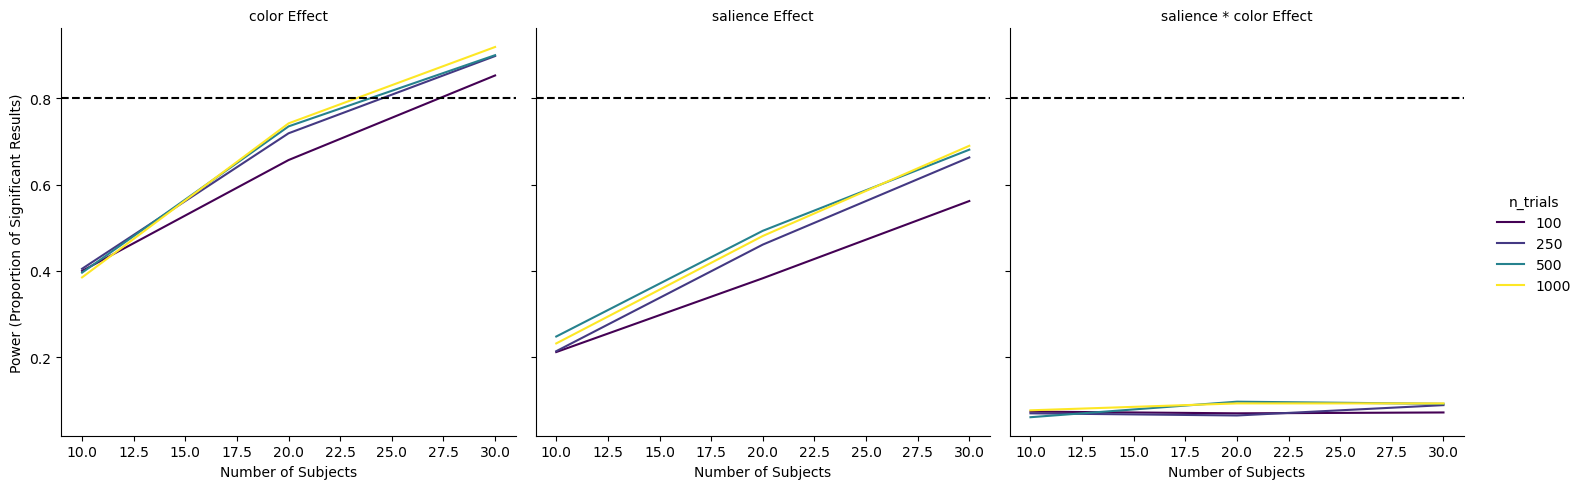

In [19]:
power_results['significant'] = power_results['p_value'] < 0.05

g = sns.relplot(data=power_results.groupby(['n_trials', 'n_subjects', 'factor'])['significant'].mean().reset_index(), x='n_subjects', y='significant', hue='n_trials', col='factor', kind='line',
            palette='viridis', markers=True, dashes=False)

g.map(plt.axhline, y=0.8, color='black', linestyle='--')

g.set_titles(col_template='{col_name} Effect')

g.set(ylabel='Power (Proportion of Significant Results)', xlabel='Number of Subjects')

In [214]:
mean_mean_rt = df[df.RT_filter].groupby(['subject_id', 'dist', 'sal'])['logRT'].mean().reset_index().groupby(['dist', 'sal'])['logRT'].mean()

sd_mean_rt = df[df.RT_filter].groupby(['subject_id', 'dist', 'sal'])['logRT'].mean().reset_index().groupby(['dist', 'sal'])['logRT'].std()

mean_sd_rt = df[df.RT_filter].groupby(['subject_id', 'dist', 'sal'])['logRT'].mean().reset_index().groupby(['dist', 'sal'])['logRT'].std()

Signature:
pg.rm_anova(
    data=None,
    dv=None,
    within=None,
    subject=None,
    correction='auto',
    detailed=False,
    effsize='ng2',
)
Docstring:
One-way and two-way repeated measures ANOVA.

Parameters
----------
data : :py:class:`pandas.DataFrame`
    DataFrame. Note that this function can also directly be used as a
    :py:class:`pandas.DataFrame` method, in which case this argument is no
    longer needed.
    Both wide and long-format dataframe are supported for one-way repeated
    measures ANOVA. However, ``data`` must be in long format for two-way
    repeated measures.
dv : string
    Name of column containing the dependent variable (only required if
    ``data`` is in long format).
within : string or list of string
    Name of column containing the within factor (only required if ``data``
    is in long format).
    If ``within`` is a single string, then compute a one-way repeated
    measures ANOVA, if ``within`` is a list with two strings,
    compute a two-

In [98]:
tmp['sal']

0       hi
1      low
2      med
3       hi
4      low
      ... 
149    med
150     hi
151    low
152    med
153    med
Name: sal, Length: 154, dtype: object

In [96]:
pg.linear_regression?

Signature:
pg.linear_regression(
    X,
    y,
    add_intercept=True,
    weights=None,
    coef_only=False,
    alpha=0.05,
    as_dataframe=True,
    remove_na=False,
    relimp=False,
)
Docstring:
(Multiple) Linear regression.

Parameters
----------
X : array_like
    Predictor(s), of shape *(n_samples, n_features)* or *(n_samples)*.
y : array_like
    Dependent variable, of shape *(n_samples)*.
add_intercept : bool
    If False, assume that the data are already centered. If True, add a
    constant term to the model. In this case, the first value in the
    output dict is the intercept of the model.

    .. note:: It is generally recommended to include a constant term
        (intercept) to the model to limit the bias and force the residual
        mean to equal zero. The intercept coefficient and p-values
        are however rarely meaningful.
weights : array_like
    An optional vector of sample weights to be used in the fitting
    process, of shape *(n_samples)*. Missing or ne

In [91]:
pg.linear_regression?

Signature:
pg.linear_regression(
    X,
    y,
    add_intercept=True,
    weights=None,
    coef_only=False,
    alpha=0.05,
    as_dataframe=True,
    remove_na=False,
    relimp=False,
)
Docstring:
(Multiple) Linear regression.

Parameters
----------
X : array_like
    Predictor(s), of shape *(n_samples, n_features)* or *(n_samples)*.
y : array_like
    Dependent variable, of shape *(n_samples)*.
add_intercept : bool
    If False, assume that the data are already centered. If True, add a
    constant term to the model. In this case, the first value in the
    output dict is the intercept of the model.

    .. note:: It is generally recommended to include a constant term
        (intercept) to the model to limit the bias and force the residual
        mean to equal zero. The intercept coefficient and p-values
        are however rarely meaningful.
weights : array_like
    An optional vector of sample weights to be used in the fitting
    process, of shape *(n_samples)*. Missing or ne

In [82]:
df

,,index,PROLIFIC_PID,agg_points,bar1,bar2,barloc,block,block_trial,condition,correct,...,trial_points,logRT,dist,sal,raw_filter,RT_filter,subject_id,salience,distractor,color
,Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
0,44,44,64c9892e8e7e06812b775c0c,0,0,1,75,0,45,1,0,...,0,7.471363,low,low,False,False,8,0.00,green,green
1,45,45,64c9892e8e7e06812b775c0c,0,0,1,125,0,46,1,0,...,0,7.469084,low,low,False,False,8,0.00,green,green
2,46,46,64c9892e8e7e06812b775c0c,0,0,1,175,0,47,1,0,...,0,7.473069,hi,hi,False,False,8,0.75,red,red
3,47,47,64c9892e8e7e06812b775c0c,29,1,0,-175,0,48,1,1,...,29,7.286192,low,low,True,True,8,0.25,green,green
4,48,48,64c9892e8e7e06812b775c0c,67,1,0,-125,0,49,1,1,...,38,7.224753,hi,low,True,True,8,0.25,red,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10005,10885,11458,6978c747e184ed4d0341f8a2,168705,1,0,75,9,453,1,1,...,107,6.527958,low,hi,True,True,19,0.75,green,green
10006,10886,11459,6978c747e184ed4d0341f8a2,168766,1,0,125,9,454,1,1,...,61,7.039660,low,low,True,True,19,0.00,green,green
10007,10887,11460,6978c747e184ed4d0341f8a2,168867,1,0,175,9,455,1,1,...,101,6.608001,nd,med,True,True,19,0.00,green,green


In [67]:
mean

logRT
dist sal          
hi   hi   6.862468
     low  6.856827
     med  6.848428
low  hi   6.845538
     low  6.834905
     med  6.830840
nd   med  6.826517

In [70]:
sns.catplot(data=df[df.RT_filter].groupby(['subject_id', 'dist', 'sal']).mean().reset_index(), x='dist', y='logRT', hue='sal', kind='point', order=['nd', 'low', 'hi'])

TypeError: agg function failed [how->mean,dtype->object]

In [ ]:
mean_mean_rt = df[df.RT_filter].groupby(['subject_id', 'dist', 'sal'])['logRT'].mean().reset_index().groupby(['dist', 'sal'])['logRT'].mean()

sd_mean_rt = df[df.RT_filter].groupby(['subject_id', 'dist', 'sal'])['logRT'].mean().reset_index().groupby(['dist', 'sal'])['logRT'].std()

In [26]:
mean_mean_rt

dist  sal
hi    hi     6.862468
      low    6.856827
      med    6.848428
low   hi     6.845538
      low    6.834905
      med    6.830840
nd    med    6.826517
Name: logRT, dtype: float64

In [ ]:
import numpy as np

def simulate_data(n_trials, n_subjects=100, mean_mean_rt=mean_mean_rt, mean_sd_rt=mean_sd_rt, sd_mean_rt=sd_mean_rt):
    data = []
    for subject_id in range(n_subjects):
        for dist in mean_mean_rt.index.get_level_values('dist').unique():
            for sal in mean_mean_rt.index.get_level_values('sal').unique():
                print(dist, sal)
                mean_rt = mean_mean_rt.loc[(dist, sal)] + np.random.normal(0, sd_mean_rt.loc[(dist, sal)])
                sd_rt = mean_sd_rt.loc[(dist, sal)]
                rts = np.random.normal(mean_rt, sd_rt, n_trials)
                for rt in rts:
                    data.append({'subject_id': subject_id, 'dist': dist, 'sal': sal, 'RT': rt})
    return pd.DataFrame(data)

In [25]:
simulate_data(10, 10)

KeyError: ('nd', 'hi')

<Axes: xlabel='logRT', ylabel='Count'>

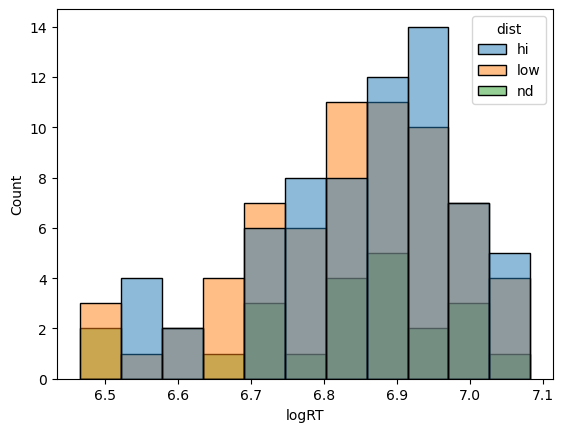

In [23]:
sns.histplot(x='logRT', data=df[df.RT_filter].groupby(['subject_id', 'dist', 'sal'])['logRT'].mean().reset_index(), hue='dist')

In [30]:
df.columns

Index(['index', 'PROLIFIC_PID', 'agg_points', 'bar1', 'bar2', 'barloc',
       'block', 'block_trial', 'condition', 'correct', 'correct_response',
       'dist_col', 'feedback', 'high_val_col', 'iti1', 'iti2',
       'jatosStudyResultId', 'loc_dist', 'loc_tar', 'low_val_col', 'id',
       'practice', 'response', 'response_age_01', 'response_age_10',
       'response_gender', 'RT', 'sessionid', 'target_dot', 'trial_nr',
       'trial_points', 'logRT', 'dist', 'sal', 'raw_filter', 'RT_filter'],
      dtype='object')

In [34]:
df['sal'].unique()

array(['low', 'hi', 'med'], dtype=object)

In [38]:
df['PROLIFIC_PID'].nunique()

22

In [32]:
df['condition'].unique()

array([1, 0])

In [15]:
from statistical_tests import (
    check_normality,
    cohens_d_ci,
    mean_diff_ci,
    eta_squared_ci,
    cousineau_morey_ci,
    paired_ttest_analysis,
    onesample_ttest_analysis,
    rm_anova_analysis
)

ModuleNotFoundError: No module named 'statistical_tests'

In [26]:
import numpy as np

import pingouin as pg

from scipy.stats import ttest_rel, ttest_1samp, f_oneway, levene, shapiro
import seaborn as sns

In [27]:
from scipy.stats import t

def cousineau_morey_ci(data, confidence=0.95):
    """
    Compute within-subject confidence intervals using the Cousineau-Morey method.

    Parameters:
    data (numpy.ndarray): A 2D array where rows are subjects and columns are conditions.
    confidence (float): The confidence level for the intervals (default is 0.95).

    Returns:
    tuple: A tuple containing the lower and upper confidence intervals for each condition.
    """
    
    n_subjects = data.shape[0]
    grand_mean = np.mean(data)
    
    # Normalize data by subtracting the subject mean and adding the grand mean
    normalized_data = data - np.mean(data, axis=1, keepdims=True) + grand_mean
    
    # Compute standard error of the mean for each condition
    sem = np.std(normalized_data, axis=0, ddof=1) / np.sqrt(n_subjects)
    
    # Compute the critical t-value for the given confidence level
    t_crit = t.ppf((1 + confidence) / 2, df=n_subjects - 1)
    
    # Compute the confidence intervals
    ci_low = np.mean(normalized_data, axis=0) - t_crit * sem
    ci_high = np.mean(normalized_data, axis=0) + t_crit * sem
    
    return ci_low, ci_high

TtestResult(statistic=-2.5371719584845525, pvalue=0.019170821122748455, df=21)
  Source            SS  DF           MS         F     p-unc       ng2  \
0   dist   8890.511323   2  4445.255662  6.671664  0.003047  0.008598   
1  Error  27984.135494  42   666.288940       NaN       NaN       NaN   

        eps  
0  0.962033  
1       NaN  
f value: 6.672
p value: 0.003
Partial Eta Squared: 0.009


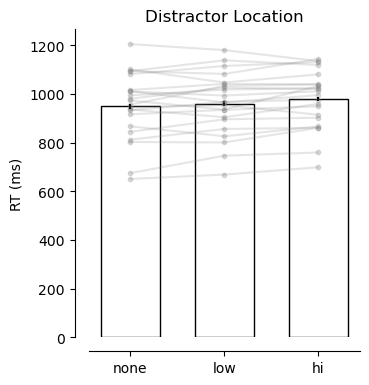

In [28]:
#this is script taken form a different experiment with different variable names, so be careful that it works with your data!

# step 1: plot results as a function of dist location 
plt.figure(figsize=(3.5, 4))
pivot = df[(df.RT_filter) & 
# (df.D_D == -1) & 
(df.correct == 1)].pivot_table(values = 'RT', columns = ['dist'], 
                    index = 'id', aggfunc='mean')

headers = [f'{cnd}' for cnd in ['nd','low','hi']]
values = [pivot[cnd].values for cnd in ['nd','low','hi']]

# Compute within-subject confidence intervals corrected using the Cousineau-Morey method
ci_low, ci_high = cousineau_morey_ci(np.array(values).T)





plt.bar([0.8,1.2,1.6], np.array(values).mean(axis = 1), width = 0.25,
            color = 'white', edgecolor = 'black', yerr=[np.array(values).mean(axis = 1) - ci_low, ci_high - np.array(values).mean(axis = 1)])

plt.scatter([[x] * len(values[0]) for x in [0.8,1.2,1.6]], values, c = 'grey', alpha = 0.25, s = 10)

plt.plot([0.8,1.2],np.array(values)[:2,:], color = 'grey', alpha = 0.2)
plt.plot([1.2,1.6],np.array(values)[1:,:], color = 'grey', alpha = 0.2)
# plt.xticks([1,2], ['biased side','neutral side'])

plt.title('Distractor Location')
plt.ylabel('RT (ms)')
plt.xticks([0.8,1.2,1.6], ['none', 'low', 'hi'])
plt.ylabel('RT (ms)')
# plt.ylim(400,600)
sns.despine(offset = 10)

print(ttest_rel(pivot['low'], pivot['hi']))
# print(ttest_rel(pivot['hp'], pivot['nd']))

# Create the AnovaRM object
pivot.reset_index(inplace=True)
pivot_long = pd.melt(pivot, id_vars=['id'], value_vars=['nd', 'low', 'hi'],
                  var_name='dist', value_name='rt')
# print(AnovaRM(pivot_long, depvar='rt', subject='total_id', within=['dist_cond']).fit())

aov = pg.rm_anova(dv='rt', within='dist', subject='id', data=pivot_long, detailed=True)
print(aov)

# Display the effect size
f_value = aov.loc[0, 'F']
p_value = aov.loc[0, 'p-unc']
eta_squared = aov.loc[0, 'ng2']
print(f"f value: {f_value:.3f}")
print(f"p value: {p_value:.3f}")
print(f"Partial Eta Squared: {eta_squared:.3f}")